<a href="https://colab.research.google.com/github/irshadali39/Customer-Churn-Prediction-Telecom/blob/main/Customer_Churn_Prediction_Telecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Description**

Customer churn is a critical problem in the telecom industry, as losing existing customers directly impacts revenue. This project aims to predict whether a customer is likely to leave a telecom service provider using customer usage, contract, and demographic data.

The project focuses on data cleaning, exploratory data analysis, and building a machine learning classification model to identify key factors influencing customer churn. The goal is to help businesses take proactive actions to improve customer retention.

**Dataset:**

Telco Customer Churn (Kaggle)

**Tools:**

 Python, Pandas, Scikit-learn, Matplotlib

**Step 1: Importing Necessary Libraries**

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Step 2: Loading the Dataset**

In [ ]:
#loading the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1             Yes                No             DSL            Yes  ...   
2             Yes                No             DSL            Yes  ...   
3              No  No phone service             DSL            Yes  ...   
4             Yes                No     Fiber optic             No  ...   
...           ...               ...             ...            ...  ...   
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0                  No          No          No              No  Month-to-month   
1                 Yes          No          No              No        One year   
2                  No          No          No              No  Month-to-month   
3                 Yes         Yes          No              No        One year   
4                  No          No          No              No  Month-to-month   
...               ...         ...         ...             ...             ...   
7038              Yes         Yes         Yes             Yes        One year   
7039              Yes          No         Yes             Yes        One year   
7040               No          No          No              No  Month-to-month   
7041               No          No          No              No  Month-to-month   
7042              Yes         Yes         Yes             Yes        Two year   

     PaperlessBilling              PaymentMethod MonthlyCharges  TotalCharges  \
0                 Yes           Electronic check          29.85         29.85   
1                  No               Mailed check          56.95        1889.5   
2                 Yes               Mailed check          53.85        108.15   
3                  No  Bank transfer (automatic)          42.30       1840.75   
4                 Yes           Electronic check          70.70        151.65   
...               ...                        ...            ...           ...   
7038              Yes               Mailed check          84.80        1990.5   
7039              Yes    Credit card (automatic)         103.20        7362.9   
7040              Yes           Electronic check          29.60        346.45   
7041              Yes               Mailed check          74.40         306.6   
7042              Yes  Bank transfer (automatic)         105.65        6844.5   

     Churn  
0       No  
1       No  
2      Yes  
3       No  
4      Yes  
...    ...  
7038    No  
7039    No  
7040    No  
7041   Yes  
7042    No  

[7043 rows x 21 columns]>

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


**Dataset Overview:**
The Telco Customer Churn dataset contains customer demographic information, account details, and service usage patterns. The target variable is Churn, which indicates whether a customer has discontinued the telecom service. Understanding the distribution of churned vs non-churned customers is essential before building a prediction model.

**Step 3: Data Cleaning & Preprocessing**

In [ ]:
# check problematic entries
df['TotalCharges'].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [ ]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


/tmp/ipython-input-419782261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
df.drop('customerID', axis=1, inplace=True)


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols


(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object'))

**Data Cleaning:**
The dataset contained non-numeric values in the TotalCharges column, which were converted to numeric format. Missing values were handled using median imputation. Irrelevant identifier columns were removed, and the target variable was encoded for machine learning compatibility

**Step 4: Exploratory Data Analysis (EDA)**

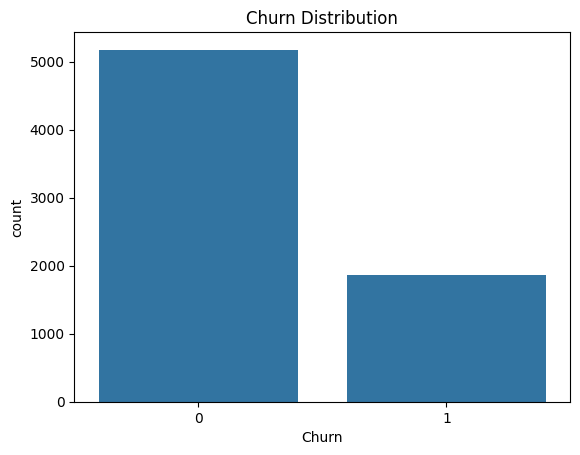

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()


**Explanation:**

This plot shows how many customers have churned versus those who stayed. It helps identify class imbalance, which is important when selecting evaluation metrics and models

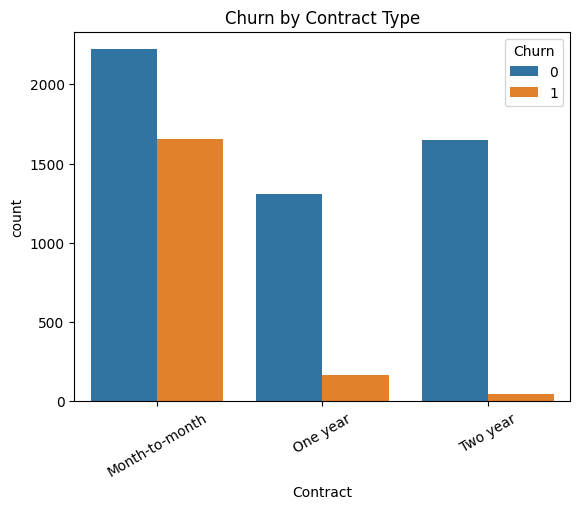

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=30)
plt.show()


**Explanation:**

This visualization shows how churn varies across different contract types. Customers on month-to-month contracts tend to churn more compared to those on long-term contracts

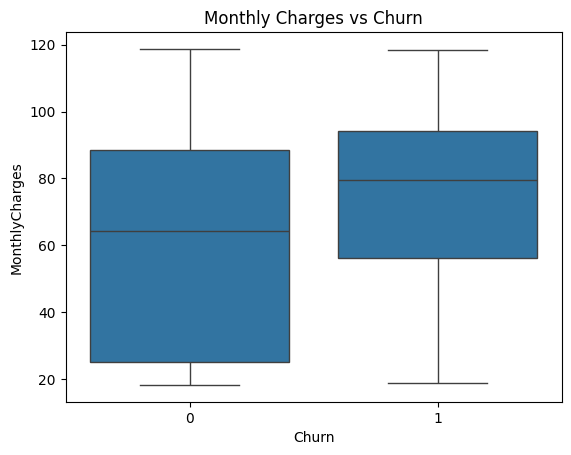

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


**Explanation:**

This boxplot compares monthly charges for churned and non-churned customers. Higher monthly charges are often associated with higher churn rates.

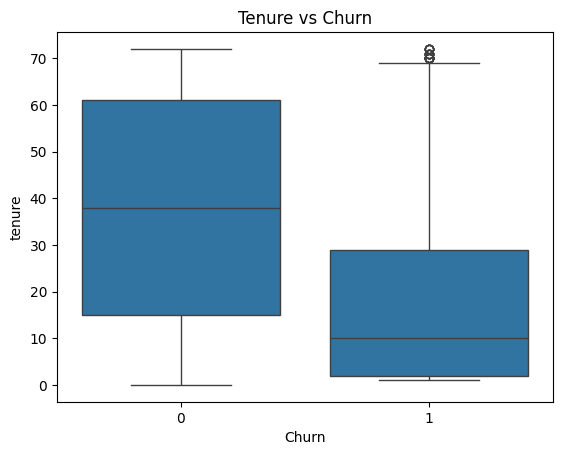

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()


**Exploratory Data Analysis Summary:**
The EDA reveals that customer churn is highly influenced by contract type, monthly charges, and tenure. Month-to-month contract customers and users with higher monthly charges show higher churn tendencies. Customers with longer tenure are more likely to remain with the service

**STEP 5: Feature Encoding & Data Preparation**

In [ ]:
# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(df, drop_first=True)


**Explanation:**

One-hot encoding converts categorical columns into numerical format by creating binary columns. The drop_first=True option avoids multicollinearity by removing one redundant category.

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


**Explanation:**

The dataset is divided into independent variables (X) and the target variable (y). This separation is necessary for training and testing machine learning models

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Explanation:**

The data is split into training and testing sets. The model is trained on 80% of the data and evaluated on the remaining 20% to measure its performance on unseen data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Explanation**

Feature scaling standardizes numerical features so that all variables contribute equally to the model. The scaler is fit only on training data to avoid data leakage

**Feature Engineering:**
Categorical variables were converted into numerical format using one-hot encoding. The dataset was split into training and testing sets, and feature scaling was applied to ensure numerical stability and improve model performance.

**STEP 6: Model Training (Logistic Regression)**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

**Explanation:**

Logistic Regression is a supervised learning algorithm used for binary classification problems. The model learns the relationship between customer features and the probability of churn. The max_iter parameter ensures the model converges properly

In [ ]:
y_pred = model.predict(X_test_scaled)


**Explanation:**

The trained model is used to predict churn labels for the test dataset, which represents unseen customer data

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8197303051809794

**Explanation:**

Accuracy measures the proportion of correct predictions made by the model. It gives a quick overview of overall performance but may not be sufficient when classes are imbalanced.

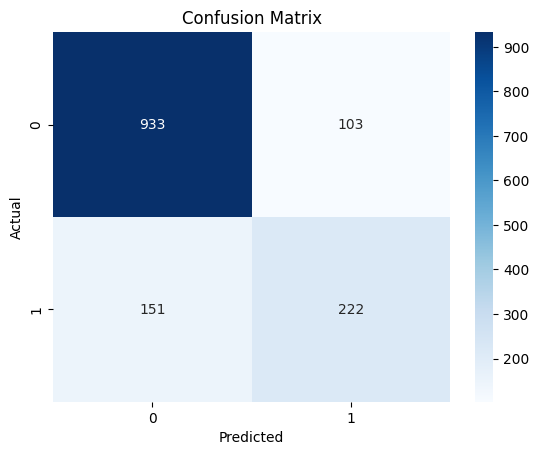

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Explanation:**

The confusion matrix shows the number of true positives, true negatives, false positives, and false negatives. It helps understand the types of errors made by the model.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



**Explanation:**

The classification report provides precision, recall, and F1-score. These metrics are more informative than accuracy, especially when the dataset is imbalanced.

**Summary**

Model Training & Evaluation:
A Logistic Regression model was trained to predict customer churn. The model performance was evaluated using accuracy, confusion matrix, and classification report. Precision, recall, and F1-score were analyzed to better understand classification performance beyond simple accuracy

**Step 7: Feature Importance (Business + ML Insights)**

In [ ]:
# Get feature names
feature_names = X.columns

# Get coefficients
coefficients = model.coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute importance
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

feature_importance.head(10)


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.326766,1.326766
2,MonthlyCharges,-0.629389,0.629389
3,TotalCharges,0.627137,0.627137
10,InternetService_Fiber optic,0.622950,0.622950
25,Contract_Two year,-0.617473,0.617473
24,Contract_One year,-0.268977,0.268977
23,StreamingMovies_Yes,0.230364,0.230364
21,StreamingTV_Yes,0.180316,0.180316
9,MultipleLines_Yes,0.168662,0.168662
26,PaperlessBilling_Yes,0.163692,0.163692


**Explanation:**

Logistic Regression assigns a coefficient to each feature, indicating its impact on churn prediction. A higher absolute coefficient means the feature has a stronger influence on the model’s decision.

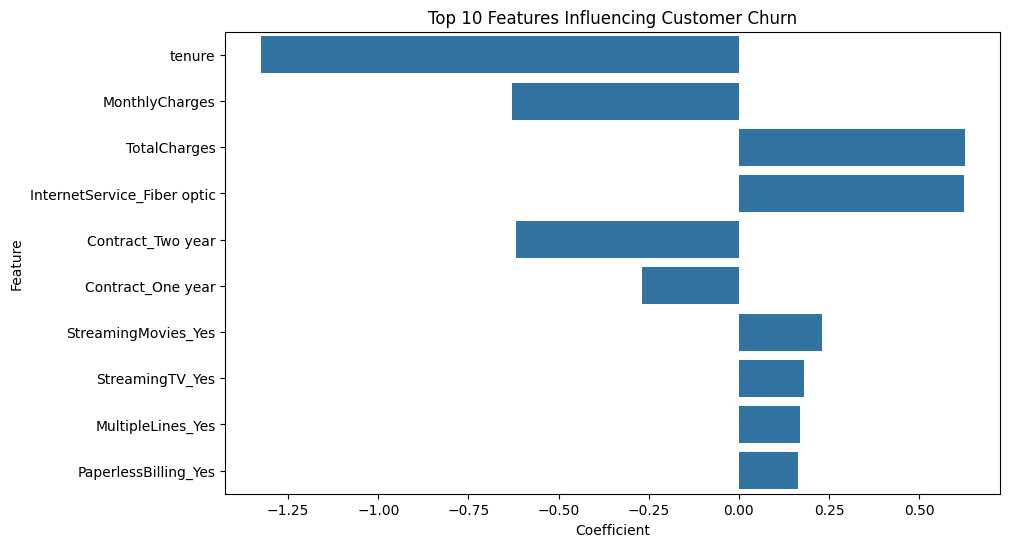

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title('Top 10 Features Influencing Customer Churn')
plt.show()


**Explanation:**

This bar chart visualizes the most influential features affecting customer churn. It helps stakeholders understand which customer attributes contribute most to churn risk

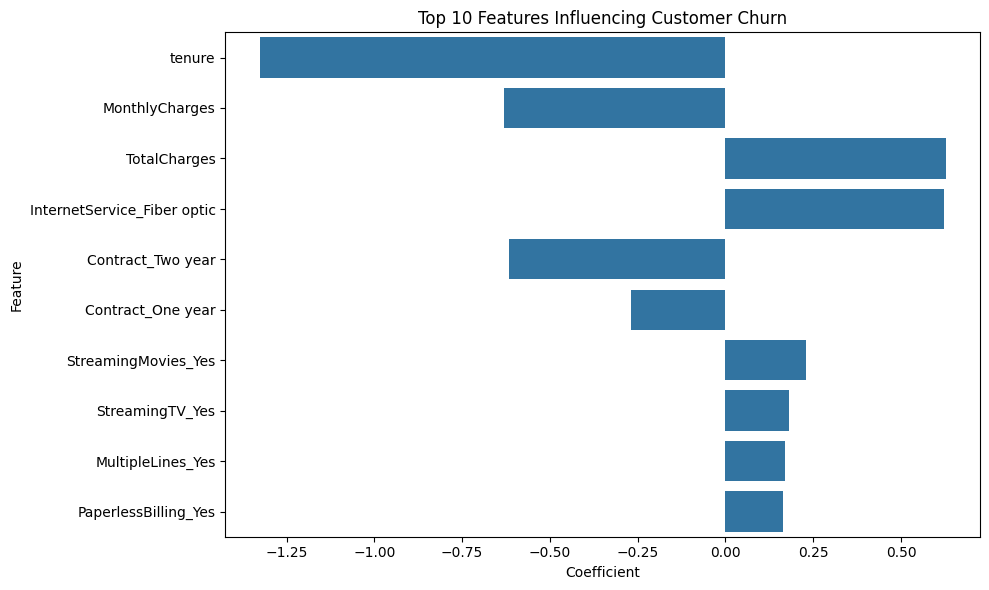

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title('Top 10 Features Influencing Customer Churn')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


**Summary**

Feature Importance Analysis:
Feature importance analysis was performed using Logistic Regression coefficients. The results show that contract type, tenure, and monthly charges are among the most significant factors influencing customer churn. This insight helps businesses design targeted retention strategies.

**Step: 8 Final Conclusion**

**Conclusion**

In this project, a machine learning model was developed to predict customer churn in the telecom industry. After data cleaning, exploratory analysis, and feature engineering, a Logistic Regression model was trained and evaluated. The analysis revealed that contract type, tenure, and monthly charges are key drivers of customer churn. This model can help telecom companies proactively identify at-risk customers and implement effective retention strategies